# YAZEL RECOVAR Integration Demo

This notebook demonstrates how RECOVAR can be used to filter false positive picks from PhaseNet.

- **RECOVAR**: Classifies waveforms to distinguish real earthquakes from noise using learned representations
- **YAZEL Integration**: Uses sliding windows to score PhaseNet picks and filter false positives

#### PhaseNet Configuration:
- **Overlap**: 0.90 (90% overlap between windows)
- **Stacking**: avg (average predictions across overlapping windows)
- **Model**: PhaseNet `instance` pretrained model


In [1]:
import obspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime

from yazel_integration_sliding import (
    recovar_pick_cleaner_sliding,
    load_recovar_classifier
)
import seisbench.models as sbm

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

2025-11-27 14:19:53.107618: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 14:19:53.146226: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-27 14:19:53.146262: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-27 14:19:53.146288: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 14:19:53.154128: I tensorflow/core/platform/cpu_feature_g

### Setup: Load Model and Data

In [2]:
# Configuration
MODEL_PATH = '/mnt/data_a/ege/recovar_models/exp_instance/representation_learning_autoencoder_ensemble/instance/split0/ep19.h5'
PHASENET_THRESHOLD = 0.32
phasenet_pick_dir = f"filtered_phasenet_picks_dir_thr_{PHASENET_THRESHOLD:.2f}"

# Load catalog for ground truth
catalog_path = '/home/boxx/Public/earthquake_model_evaluations/data/SilivriPaper_2019-09-01__2019-11-30/processed_catalogs/kara74a_phase_picks.csv'
catalog = pd.read_csv(catalog_path)
catalog['p_arrival_time'] = pd.to_datetime(catalog['p_arrival_time'])

# Load PhaseNet picks metadata
phasenet_picks = pd.read_csv(f"{phasenet_pick_dir}/metadata.csv")

print(f"Loaded {len(phasenet_picks)} PhaseNet picks")
print(f"Loaded {len(catalog)} catalog picks")

Loaded 2214 PhaseNet picks
Loaded 8540 catalog picks


In [3]:
# Load RECOVAR classifier
print("Loading RECOVAR classifier...")
classifier = load_recovar_classifier(MODEL_PATH)
print("Classifier loaded successfully!")

Loading RECOVAR classifier...


2025-11-27 14:20:07.860486: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16953 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6
2025-11-27 14:20:07.861485: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 15929 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-11-27 14:20:07.862459: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22286 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6
2025-11-27 14:20:07.863082: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 135 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090, 

Classifier loaded successfully!


In [4]:
# Load PhaseNet model
print("Loading PhaseNet model...")
phasenet_model = sbm.PhaseNet.from_pretrained('instance')
print("PhaseNet model loaded successfully!")

Loading PhaseNet model...
PhaseNet model loaded successfully!


## Select Example Picks

For this demonstration, we'll select:
1. **True Positives (TP)**: PhaseNet picks that match catalog events
2. **False Positives (FP)**: PhaseNet picks without catalog events

In [5]:
# Load and categorize picks
p = Path(phasenet_pick_dir)
files = sorted([f for f in p.iterdir() if f.is_file() and f.suffix == '.mseed'])

tp_examples = []
fp_examples = []

for file in files[:50]:  # Check first 50 files
    pick_row = phasenet_picks[phasenet_picks['filename'] == file.name]
    if pick_row.empty:
        continue
    
    try:
        stream = obspy.read(file)
        stream.merge()
        station = stream[0].stats.station
        
        phasenet_pick = pd.to_datetime(pick_row['pick_time'].values[0], format='mixed')
        window_start = pd.to_datetime(pick_row['start_time'].values[0], format='mixed')
        window_end = pd.to_datetime(pick_row['end_time'].values[0], format='mixed')
        
        # Check if there's a catalog pick in this window
        catalog_picks = catalog[
            (catalog['station'] == station) &
            (catalog['p_arrival_time'] >= window_start) &
            (catalog['p_arrival_time'] <= window_end)
        ]
        
        example = {
            'file': file,
            'stream': stream,
            'station': station,
            'phasenet_pick': phasenet_pick,
            'window_start': window_start,
            'window_end': window_end,
            'catalog_pick': catalog_picks.iloc[0]['p_arrival_time'] if not catalog_picks.empty else None
        }
        
        if not catalog_picks.empty:
            tp_examples.append(example)
        else:
            fp_examples.append(example)
            
    except Exception as e:
        continue
    
    if len(tp_examples) >= 3 and len(fp_examples) >= 3:
        break

print(f"Found {len(tp_examples)} True Positive examples")
print(f"Found {len(fp_examples)} False Positive examples")

Found 3 True Positive examples
Found 46 False Positive examples


## Timing Test: Single Sliding Window

Let's measure how long it takes to process one waveform with sliding windows.

In [6]:
if tp_examples:
    test_stream = tp_examples[0]['stream'].copy()
    
    print("Testing sliding window processing time...")
    start_time = time.time()
    result = recovar_pick_cleaner_sliding(test_stream, classifier)
    elapsed_time = time.time() - start_time
    
    print(f"\nProcessing completed in {elapsed_time:.3f} seconds")
    print(f"Number of windows: {len(result['scores_array'])}")
    print(f"Time per window: {elapsed_time / len(result['scores_array']) * 1000:.2f} ms")
    print(f"\nScores:")
    print(f"  Mean: {result['mean_score']:.4f}")
    print(f"  Max:  {result['max_score']:.4f}")
    print(f"  Min:  {np.min(result['scores_array']):.4f}")

Testing sliding window processing time...

Processing completed in 1.284 seconds
Number of windows: 31
Time per window: 41.43 ms

Scores:
  Mean: 0.1621
  Max:  0.2732
  Min:  0.0082


In [8]:
def get_phasenet_probabilities(stream, model, overlap=0.90):
    """
    Get PhaseNet P-wave probability curve for a stream using sliding windows.
    
    Parameters:
    -----------
    stream : obspy.Stream
        Input waveform stream (3 components)
    model : seisbench.models.PhaseNet
        PhaseNet model instance
    overlap : float
        Overlap fraction between windows (default: 0.90)
    
    Returns:
    --------
    dict with 'p_prob' (P-wave probabilities), 'times' (time array in seconds)
    """
    stream_sync = stream.copy()
    stream_sync.merge(method=1, fill_value=0)
    stream_sync.trim(
        starttime=max([tr.stats.starttime for tr in stream_sync]),
        endtime=min([tr.stats.endtime for tr in stream_sync]),
        pad=True,
        fill_value=0
    )
    
    # Run PhaseNet with sliding window parameters (no blinding to match integration codebase)
    annotations = model.annotate(stream_sync, overlap=overlap)
    
    # Extract P-wave probabilities
    p_trace = [tr for tr in annotations if tr.stats.channel.endswith('P')][0]
    
    sampling_rate = p_trace.stats.sampling_rate
    times = np.arange(len(p_trace.data)) / sampling_rate
    
    return {
        'p_prob': p_trace.data,
        's_prob': [tr for tr in annotations if tr.stats.channel.endswith('S')][0].data,
        'times': times,
        'sampling_rate': sampling_rate
    }

print("PhaseNet probability extraction function ready!")

PhaseNet probability extraction function ready!


In [9]:
# Also time PhaseNet processing
if tp_examples:
    test_stream = tp_examples[0]['stream'].copy()
    
    print("\nTesting PhaseNet processing time (overlap=0.90)...")
    start_time = time.time()
    phasenet_result = get_phasenet_probabilities(test_stream, phasenet_model, overlap=0.90)
    elapsed_time = time.time() - start_time
    
    print(f"Processing completed in {elapsed_time:.3f} seconds")
    print(f"Number of probability samples: {len(phasenet_result['p_prob'])}")
    print(f"Max P-probability: {np.max(phasenet_result['p_prob']):.4f}")
    
    print("\n=== TIMING COMPARISON ===")
    print("Both methods process the same 60-second waveform window")
    print("PhaseNet provides continuous probability curves")
    print("RECOVAR provides discrete window scores for robust classification")


Testing PhaseNet processing time (overlap=0.90)...
Processing completed in 0.064 seconds
Number of probability samples: 6499
Max P-probability: 0.9350

=== TIMING COMPARISON ===
Both methods process the same 60-second waveform window
PhaseNet provides continuous probability curves
RECOVAR provides discrete window scores for robust classification


## Visualization

### True Positive Example (Real Earthquake)

## PhaseNet Probability Extraction

Function to get PhaseNet P-wave probabilities over time using sliding windows.

Processing True Positive example...


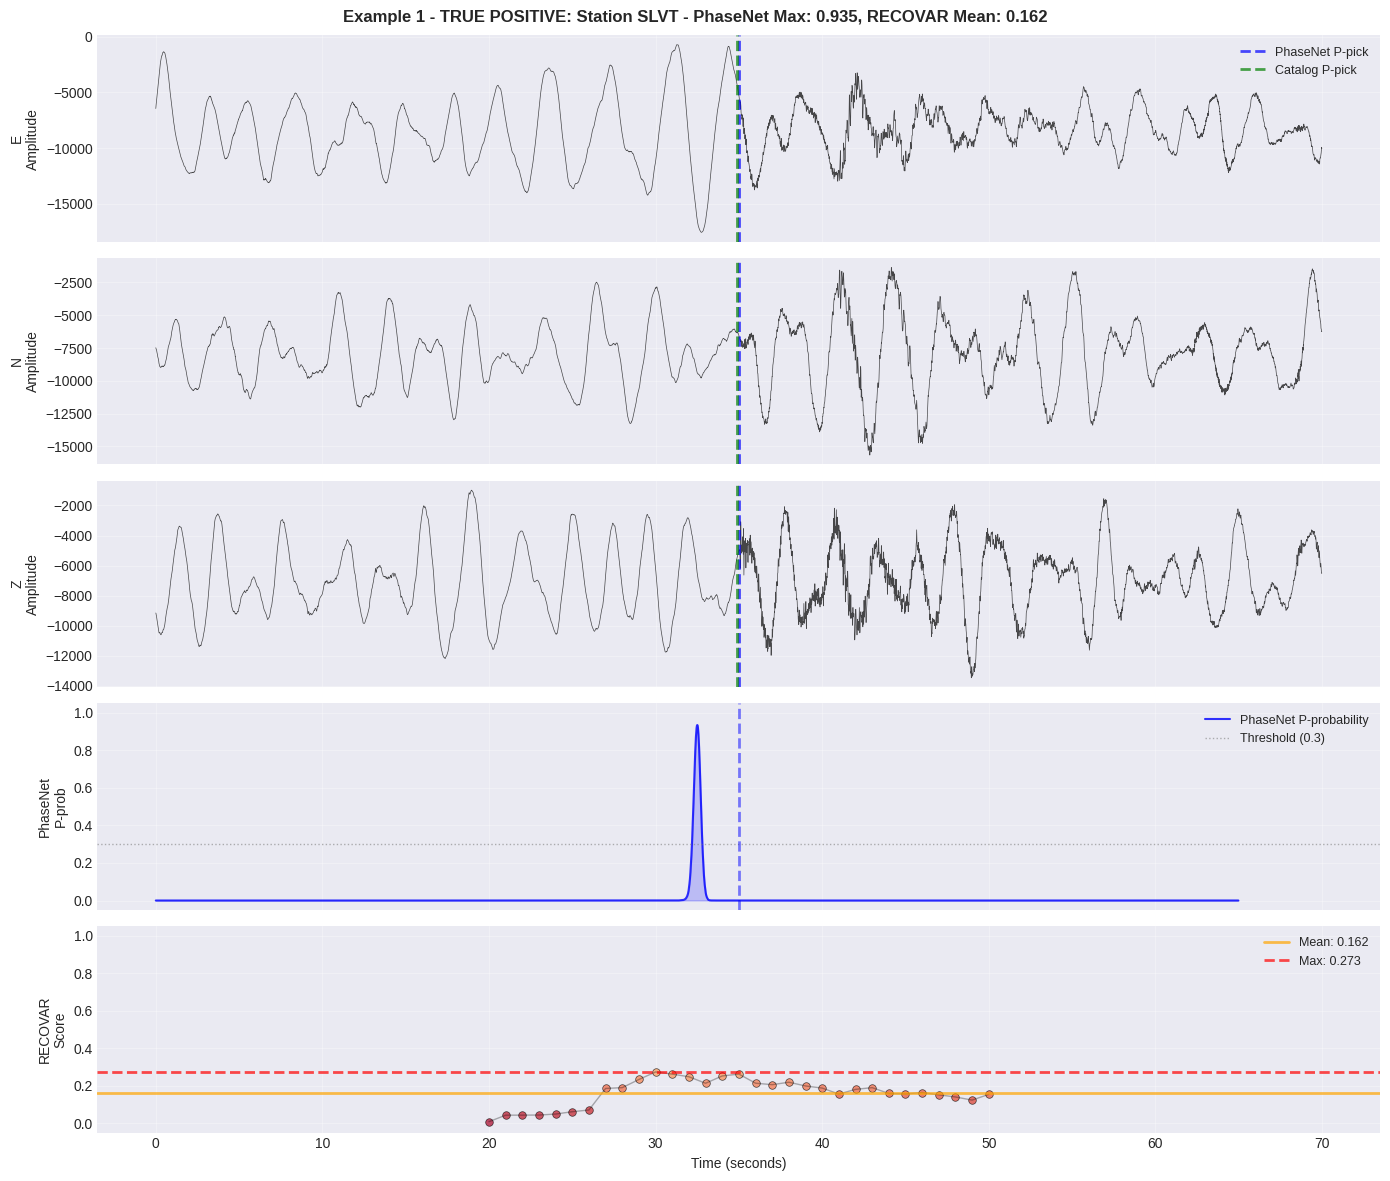

In [17]:
def plot_waveform_with_scores(example, recovar_result, phasenet_result, title_prefix=""):
    """
    Plot waveform with PhaseNet probabilities and RECOVAR scores overlay.
    """
    stream = example['stream']
    z_trace = stream.select(channel="*Z")[0]
    n_trace = stream.select(channel="*N")[0]
    e_trace = stream.select(channel="*E")[0]
    
    # Time arrays
    sampling_rate = z_trace.stats.sampling_rate
    times = np.arange(len(z_trace.data)) / sampling_rate
    
    # Calculate pick positions
    window_start = example['window_start']
    phasenet_pick = example['phasenet_pick']
    catalog_pick = example['catalog_pick']
    
    phasenet_pick_sec = (phasenet_pick - window_start).total_seconds()
    if catalog_pick:
        catalog_pick_sec = (catalog_pick - window_start).total_seconds()
    
    # Sliding window parameters for RECOVAR
    window_size = 3000  # 30 seconds at 100 Hz
    stride = 100  # 1 second at 100 Hz
    trim_samples = 500  # 5 seconds
    
    # Calculate window centers for RECOVAR score overlay
    n_windows = len(recovar_result['scores_array'])
    window_centers = []
    for i in range(n_windows):
        start_idx = i * stride
        center_idx = start_idx + window_size // 2 + trim_samples
        window_centers.append(center_idx / sampling_rate)
    
    scores = recovar_result['scores_array']
    
    # Create figure with 5 panels
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    
    # Plot waveforms
    for ax, trace, comp in zip(axes[:3], [e_trace, n_trace, z_trace], ['E', 'N', 'Z']):
        ax.plot(times, trace.data, 'k-', linewidth=0.5, alpha=0.7)
        ax.set_ylabel(f'{comp}\nAmplitude', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Mark PhaseNet pick
        ax.axvline(phasenet_pick_sec, color='blue', linestyle='--', 
                   linewidth=2, label='PhaseNet P-pick', alpha=0.7)
        
        # Mark catalog pick if exists
        if catalog_pick:
            ax.axvline(catalog_pick_sec, color='green', linestyle='--', 
                       linewidth=2, label='Catalog P-pick', alpha=0.7)
        
        if comp == 'E':
            ax.legend(loc='upper right', fontsize=9)
    
    # Plot PhaseNet P-probabilities
    ax_phasenet = axes[3]
    pn_times = phasenet_result['times']
    pn_probs = phasenet_result['p_prob']
    
    ax_phasenet.plot(pn_times, pn_probs, 'b-', linewidth=1.5, alpha=0.8, label='PhaseNet P-probability')
    ax_phasenet.fill_between(pn_times, 0, pn_probs, color='blue', alpha=0.2)
    ax_phasenet.axhline(0.3, color='gray', linestyle=':', linewidth=1, label='Threshold (0.3)', alpha=0.6)
    ax_phasenet.axvline(phasenet_pick_sec, color='blue', linestyle='--', linewidth=2, alpha=0.5)
    
    ax_phasenet.set_ylabel('PhaseNet\nP-prob', fontsize=10)
    ax_phasenet.set_ylim(-0.05, 1.05)
    ax_phasenet.grid(True, alpha=0.3)
    ax_phasenet.legend(loc='upper right', fontsize=9)
    
    # Plot RECOVAR scores
    ax_score = axes[4]
    
    # Color-code by score value
    colors = plt.cm.RdYlGn(scores)  # Red (low) to Green (high)
    
    for i in range(len(window_centers)):
        ax_score.scatter(window_centers[i], scores[i], c=[colors[i]], 
                        s=30, alpha=0.7, edgecolors='black', linewidths=0.5)
    
    ax_score.plot(window_centers, scores, 'k-', linewidth=1, alpha=0.3)
    ax_score.axhline(recovar_result['mean_score'], color='orange', linestyle='-', 
                     linewidth=2, label=f"Mean: {recovar_result['mean_score']:.3f}", alpha=0.7)
    ax_score.axhline(recovar_result['max_score'], color='red', linestyle='--', 
                     linewidth=2, label=f"Max: {recovar_result['max_score']:.3f}", alpha=0.7)
    
    ax_score.set_ylabel('RECOVAR\nScore', fontsize=10)
    ax_score.set_xlabel('Time (seconds)', fontsize=10)
    ax_score.set_ylim(-0.05, 1.05)
    ax_score.grid(True, alpha=0.3)
    ax_score.legend(loc='upper right', fontsize=9)
    

    
    # Title
    status = "TRUE POSITIVE" if catalog_pick else "FALSE POSITIVE"
    fig.suptitle(f"{title_prefix}{status}: Station {example['station']} - "
                 f"PhaseNet Max: {np.max(pn_probs):.3f}, RECOVAR Mean: {recovar_result['mean_score']:.3f}",
                 fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot first True Positive
if tp_examples:
    print("Processing True Positive example...")
    tp_recovar = recovar_pick_cleaner_sliding(tp_examples[0]['stream'], classifier)
    tp_phasenet = get_phasenet_probabilities(tp_examples[0]['stream'], phasenet_model, overlap=0.90)
    plot_waveform_with_scores(tp_examples[0], tp_recovar, tp_phasenet, "Example 1 - ")

### False Positive Example (Noise/Artifact)

Processing False Positive example...


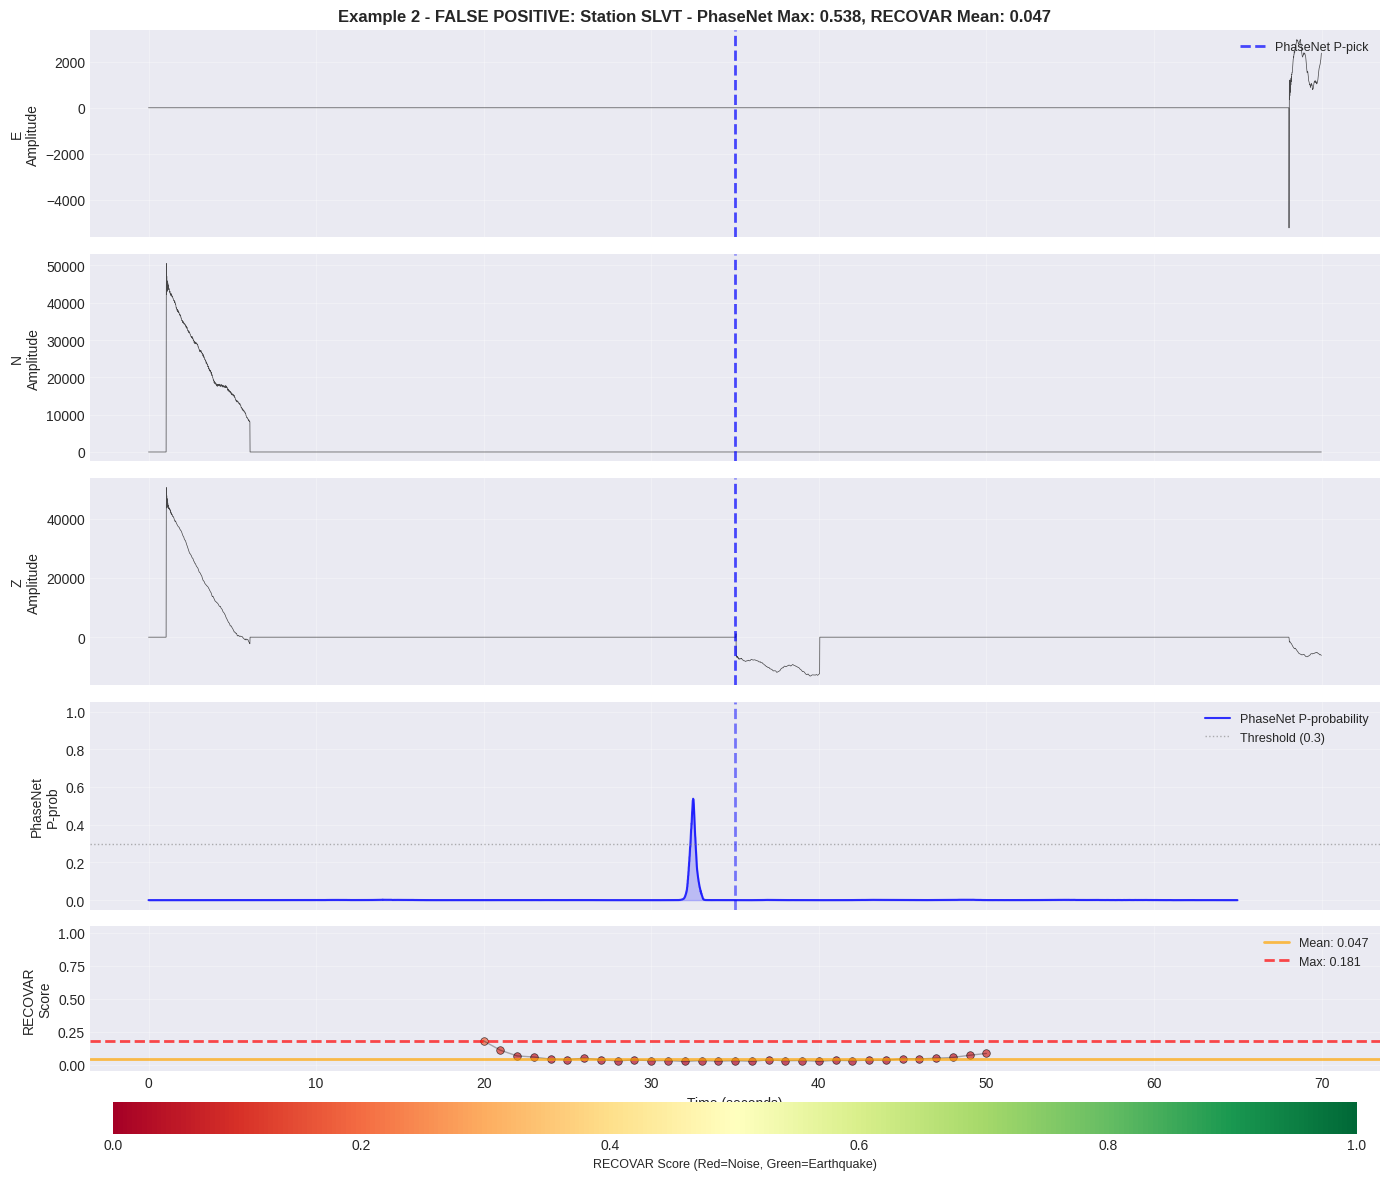

In [16]:
# Plot first False Positive
if fp_examples:
    print("Processing False Positive example...")
    fp_recovar = recovar_pick_cleaner_sliding(fp_examples[2]['stream'], classifier)
    fp_phasenet = get_phasenet_probabilities(fp_examples[2]['stream'], phasenet_model, overlap=0.90)
    plot_waveform_with_scores(fp_examples[2], fp_recovar, fp_phasenet, "Example 2 - ")

## Comparison: True Positives vs False Positives

Let's process multiple examples and compare the score distributions.

In [12]:
# Process all examples
tp_results = []
fp_results = []

print("Processing True Positives...")
for example in tp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    tp_results.append(result)

print("Processing False Positives...")
for example in fp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    fp_results.append(result)

# Extract scores
tp_mean_scores = [r['mean_score'] for r in tp_results]
tp_max_scores = [r['max_score'] for r in tp_results]
fp_mean_scores = [r['mean_score'] for r in fp_results]
fp_max_scores = [r['max_score'] for r in fp_results]

print(f"\nProcessed {len(tp_results)} True Positives and {len(fp_results)} False Positives")

Processing True Positives...
Processing False Positives...

Processed 3 True Positives and 46 False Positives


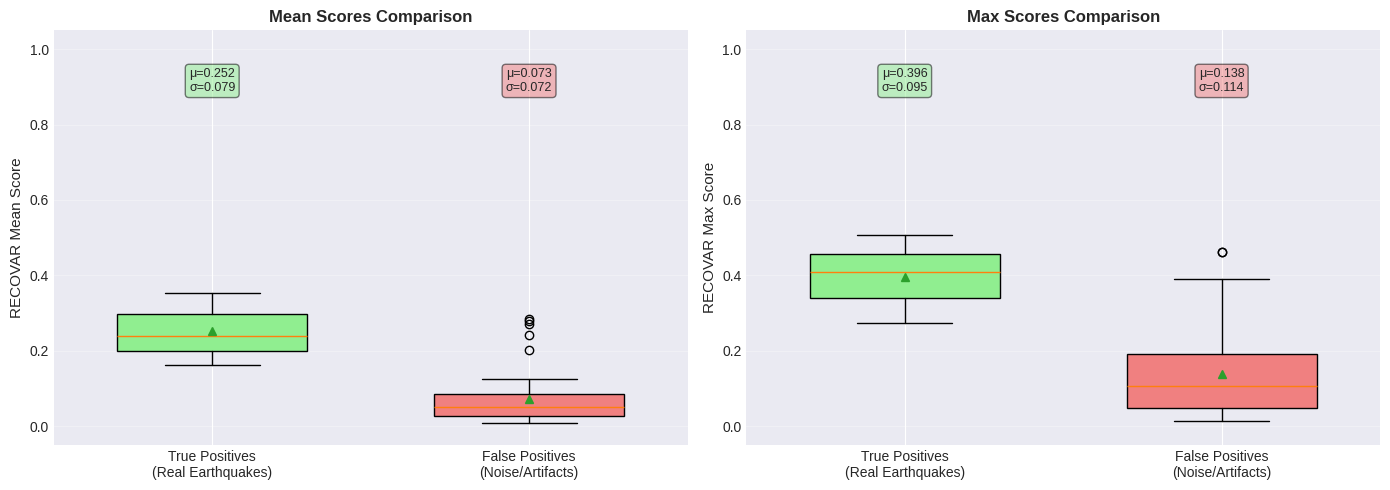


=== SCORE STATISTICS ===

True Positives (Real Earthquakes):
  Mean scores: μ=0.252, σ=0.079
  Max scores:  μ=0.396, σ=0.095

False Positives (Noise/Artifacts):
  Mean scores: μ=0.073, σ=0.072
  Max scores:  μ=0.138, σ=0.114


In [13]:
# Plot score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean scores
ax = axes[0]
positions = [1, 2]
box_data = [tp_mean_scores, fp_mean_scores]
bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True)

# Color boxes
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(['True Positives\n(Real Earthquakes)', 
                    'False Positives\n(Noise/Artifacts)'])
ax.set_ylabel('RECOVAR Mean Score', fontsize=11)
ax.set_title('Mean Scores Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.05, 1.05)

# Add statistics
if tp_mean_scores:
    ax.text(1, 0.95, f'μ={np.mean(tp_mean_scores):.3f}\nσ={np.std(tp_mean_scores):.3f}',
            ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
if fp_mean_scores:
    ax.text(2, 0.95, f'μ={np.mean(fp_mean_scores):.3f}\nσ={np.std(fp_mean_scores):.3f}',
            ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# Max scores
ax = axes[1]
box_data = [tp_max_scores, fp_max_scores]
bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(['True Positives\n(Real Earthquakes)', 
                    'False Positives\n(Noise/Artifacts)'])
ax.set_ylabel('RECOVAR Max Score', fontsize=11)
ax.set_title('Max Scores Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.05, 1.05)

# Add statistics
if tp_max_scores:
    ax.text(1, 0.95, f'μ={np.mean(tp_max_scores):.3f}\nσ={np.std(tp_max_scores):.3f}',
            ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
if fp_max_scores:
    ax.text(2, 0.95, f'μ={np.mean(fp_max_scores):.3f}\nσ={np.std(fp_max_scores):.3f}',
            ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== SCORE STATISTICS ===")
print("\nTrue Positives (Real Earthquakes):")
if tp_mean_scores:
    print(f"  Mean scores: μ={np.mean(tp_mean_scores):.3f}, σ={np.std(tp_mean_scores):.3f}")
    print(f"  Max scores:  μ={np.mean(tp_max_scores):.3f}, σ={np.std(tp_max_scores):.3f}")

print("\nFalse Positives (Noise/Artifacts):")
if fp_mean_scores:
    print(f"  Mean scores: μ={np.mean(fp_mean_scores):.3f}, σ={np.std(fp_mean_scores):.3f}")
    print(f"  Max scores:  μ={np.mean(fp_max_scores):.3f}, σ={np.std(fp_max_scores):.3f}")

## Threshold Selection

Based on the score distributions, we can select a threshold to filter false positives while retaining true positives.

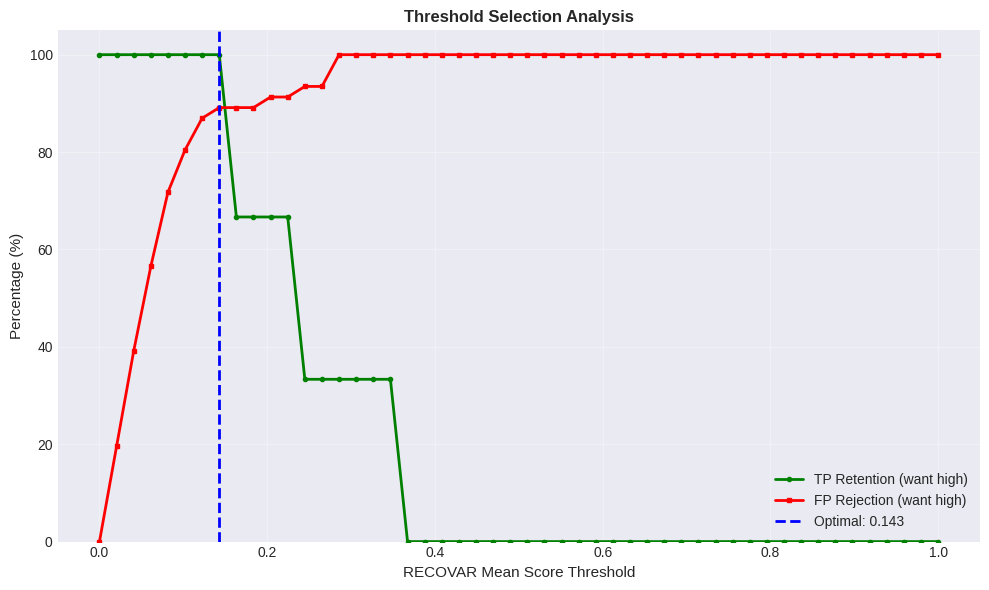


Optimal threshold: 0.143
  TP retained: 100.0%
  FP rejected: 89.1%


In [14]:
# Test different thresholds
if tp_mean_scores and fp_mean_scores:
    thresholds = np.linspace(0, 1, 50)
    tp_retention = []
    fp_rejection = []
    
    for thr in thresholds:
        tp_kept = np.sum(np.array(tp_mean_scores) >= thr) / len(tp_mean_scores)
        fp_rejected = np.sum(np.array(fp_mean_scores) < thr) / len(fp_mean_scores)
        tp_retention.append(tp_kept * 100)
        fp_rejection.append(fp_rejected * 100)
    
    # Plot threshold performance
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(thresholds, tp_retention, 'g-', linewidth=2, 
            label='TP Retention (want high)', marker='o', markersize=3)
    ax.plot(thresholds, fp_rejection, 'r-', linewidth=2, 
            label='FP Rejection (want high)', marker='s', markersize=3)
    
    # Find optimal threshold (maximize sum)
    combined = np.array(tp_retention) + np.array(fp_rejection)
    optimal_idx = np.argmax(combined)
    optimal_thr = thresholds[optimal_idx]
    
    ax.axvline(optimal_thr, color='blue', linestyle='--', linewidth=2,
               label=f'Optimal: {optimal_thr:.3f}')
    
    ax.set_xlabel('RECOVAR Mean Score Threshold', fontsize=11)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Threshold Selection Analysis', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal threshold: {optimal_thr:.3f}")
    print(f"  TP retained: {tp_retention[optimal_idx]:.1f}%")
    print(f"  FP rejected: {fp_rejection[optimal_idx]:.1f}%")

## Summary

- Sliding windows (both PhaseNet and RECOVAR) provide better scoring by analyzing multiple time positions
- A well-chosen threshold can filter many false positives while retaining most true positives

For batch processing and full evaluation, see `run_yazel_batch_sliding.py`